In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Ventas generales: tickets y horarios
Comparación de ventas cerradas entre 2025 y 2026 usando la hora de creación del ticket.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

BASE = '/content/drive/MyDrive/Portfolio/02_Restaurant_Sales/data'

In [3]:
df = pd.read_excel(f'{BASE}/VENTAS_2025.xls', sheet_name='Ventas', skiprows=3)
df_26 = pd.read_excel(f'{BASE}/VENTAS_ANUAL_2026.xlsx', sheet_name='Ventas', skiprows=3)

df['Total'] = pd.to_numeric(df['Total'], errors='coerce')
df['Creación'] = pd.to_datetime(df['Creación'])
df = df[(df['Estado'] == 'Cerrada') & (df['Total'] > 0)].copy()

df['Fecha'] = df['Creación'].dt.normalize()
df['Mes'] = df['Creación'].dt.month
df['Dia'] = df['Creación'].dt.day
df['Dia_semana'] = df['Creación'].dt.dayofweek
df['Hora'] = df['Creación'].dt.hour

df_26['Total'] = pd.to_numeric(df_26['Total'], errors='coerce')
df_26['Creación'] = pd.to_datetime(df_26['Creación'])
df_26 = df_26[(df_26['Estado'] == 'Cerrada') & (df_26['Total'] > 0)].copy()

df_26['Fecha'] = df_26['Creación'].dt.normalize()
df_26['Mes'] = df_26['Creación'].dt.month
df_26['Dia'] = df_26['Creación'].dt.day
df_26['Dia_semana'] = df_26['Creación'].dt.dayofweek
df_26['Hora'] = df_26['Creación'].dt.hour

Se compara enero al último mes completo disponible en 2026.

In [4]:
fecha_max = df_26['Fecha'].max()
ultimo_mes = fecha_max.month - 1

df_25 = df[df['Mes'] <= ultimo_mes].copy()
df_26_comp = df_26[df_26['Mes'] <= ultimo_mes].copy()

print(f'Periodo comparable: enero a mes {ultimo_mes} de cada año')

Periodo comparable: enero a mes 9 de cada año


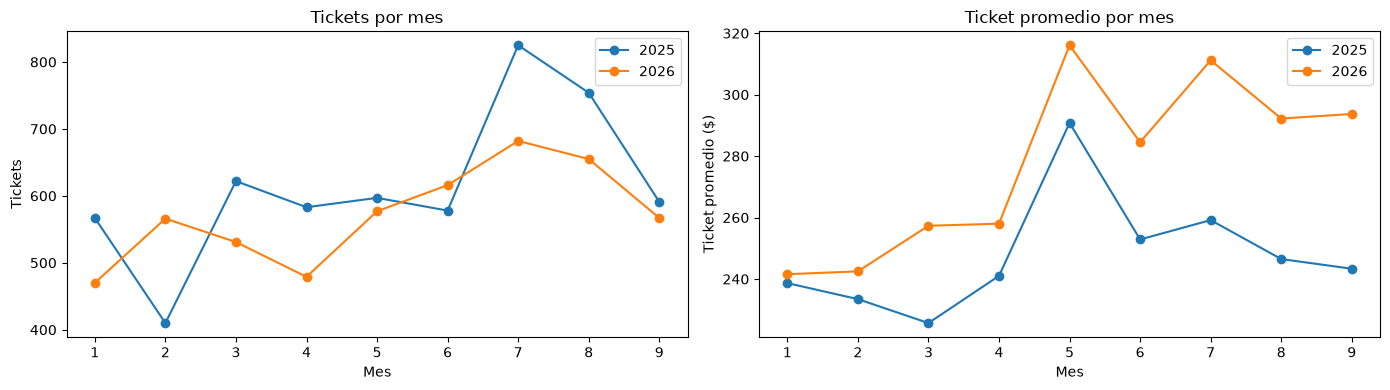

In [5]:
meses = range(1, ultimo_mes + 1)

ventas_mes_25 = df_25.groupby('Mes').agg(
    tickets=('Id', 'nunique'),
    ticket_prom=('Total', 'mean')
).reindex(meses)

ventas_mes_26 = df_26_comp.groupby('Mes').agg(
    tickets=('Id', 'nunique'),
    ticket_prom=('Total', 'mean')
).reindex(meses)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(meses, ventas_mes_25['tickets'], marker='o', label='2025')
ax[0].plot(meses, ventas_mes_26['tickets'], marker='o', label='2026')
ax[0].set_title('Tickets por mes')
ax[0].set_xlabel('Mes')
ax[0].set_ylabel('Tickets')
ax[0].set_xticks(meses)
ax[0].legend()

ax[1].plot(meses, ventas_mes_25['ticket_prom'], marker='o', label='2025')
ax[1].plot(meses, ventas_mes_26['ticket_prom'], marker='o', label='2026')
ax[1].set_title('Ticket promedio por mes')
ax[1].set_xlabel('Mes')
ax[1].set_ylabel('Ticket promedio ($)')
ax[1].set_xticks(meses)
ax[1].legend()

plt.tight_layout()
plt.show()

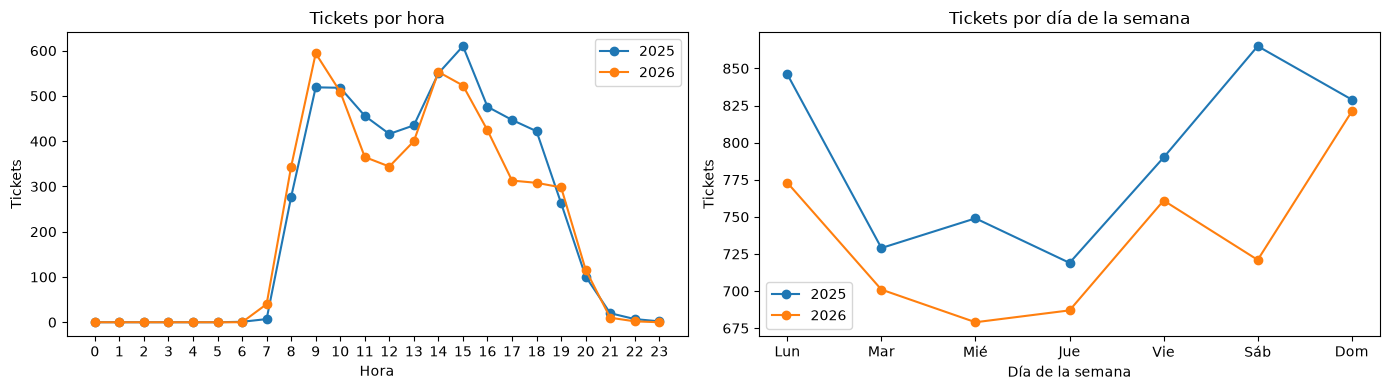

In [6]:
horas = range(24)
dias = range(7)
nombres_dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

por_hora_25 = df_25.groupby('Hora')['Id'].nunique().reindex(horas, fill_value=0)
por_hora_26 = df_26_comp.groupby('Hora')['Id'].nunique().reindex(horas, fill_value=0)

por_dia_25 = df_25.groupby('Dia_semana')['Id'].nunique().reindex(dias, fill_value=0)
por_dia_26 = df_26_comp.groupby('Dia_semana')['Id'].nunique().reindex(dias, fill_value=0)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(horas, por_hora_25, marker='o', label='2025')
ax[0].plot(horas, por_hora_26, marker='o', label='2026')
ax[0].set_title('Tickets por hora')
ax[0].set_xlabel('Hora')
ax[0].set_ylabel('Tickets')
ax[0].set_xticks(horas)
ax[0].legend()

ax[1].plot(dias, por_dia_25, marker='o', label='2025')
ax[1].plot(dias, por_dia_26, marker='o', label='2026')
ax[1].set_title('Tickets por día de la semana')
ax[1].set_xlabel('Día de la semana')
ax[1].set_ylabel('Tickets')
ax[1].set_xticks(dias)
ax[1].set_xticklabels(nombres_dias)
ax[1].legend()

plt.tight_layout()
plt.show()

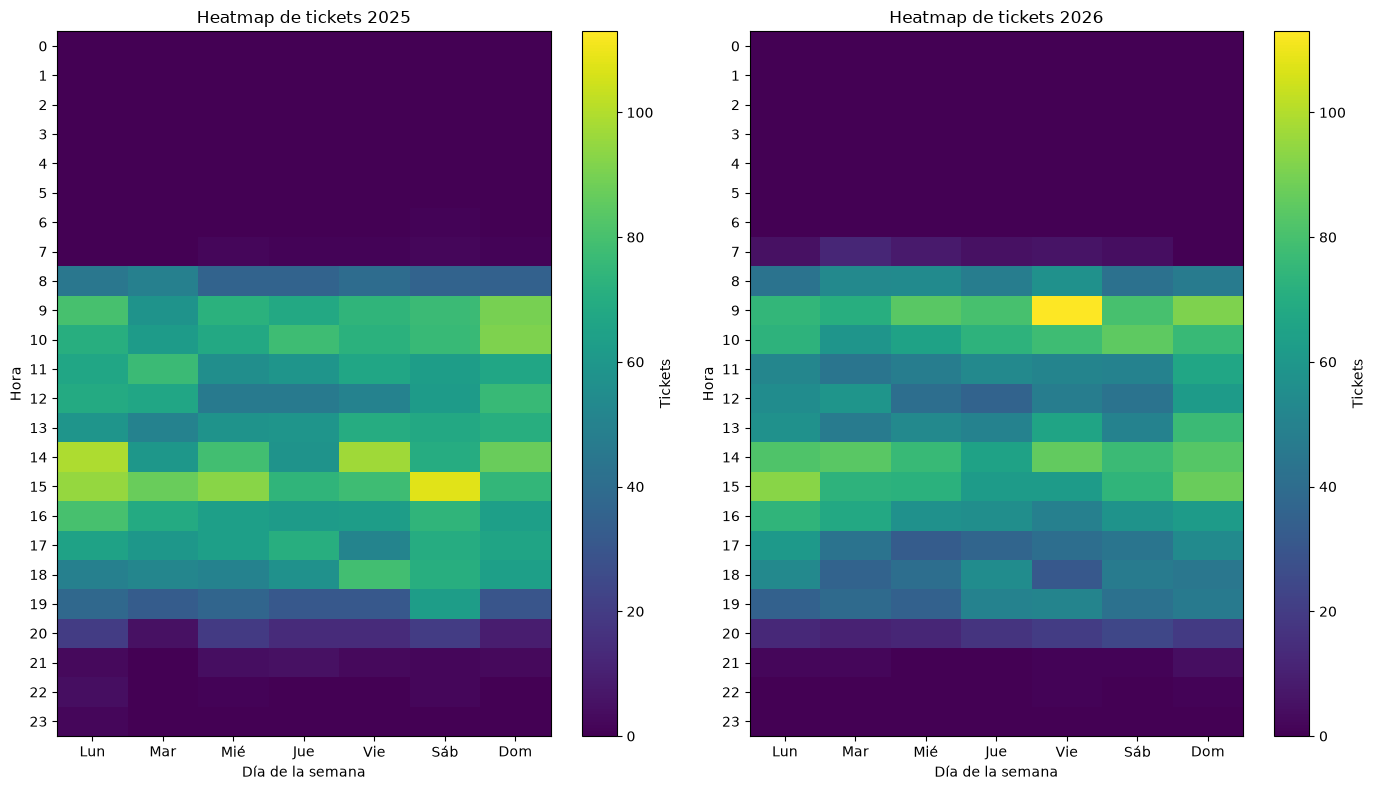

In [7]:
calor_25 = df_25.groupby(['Hora', 'Dia_semana'])['Id'].nunique().unstack(fill_value=0)
calor_25 = calor_25.reindex(index=horas, columns=dias, fill_value=0)

calor_26 = df_26_comp.groupby(['Hora', 'Dia_semana'])['Id'].nunique().unstack(fill_value=0)
calor_26 = calor_26.reindex(index=horas, columns=dias, fill_value=0)

maximo = max(calor_25.to_numpy().max(), calor_26.to_numpy().max())

fig, ax = plt.subplots(1, 2, figsize=(14, 8))

img = ax[0].imshow(calor_25, aspect='auto', vmin=0, vmax=maximo)
ax[0].set_title('Heatmap de tickets 2025')
ax[0].set_xlabel('Día de la semana')
ax[0].set_ylabel('Hora')
ax[0].set_xticks(dias)
ax[0].set_xticklabels(nombres_dias)
ax[0].set_yticks(horas)
barra = fig.colorbar(img, ax=ax[0])
barra.set_label('Tickets')

img = ax[1].imshow(calor_26, aspect='auto', vmin=0, vmax=maximo)
ax[1].set_title('Heatmap de tickets 2026')
ax[1].set_xlabel('Día de la semana')
ax[1].set_ylabel('Hora')
ax[1].set_xticks(dias)
ax[1].set_xticklabels(nombres_dias)
ax[1].set_yticks(horas)
barra = fig.colorbar(img, ax=ax[1])
barra.set_label('Tickets')

plt.tight_layout()
plt.show()

## Verificación de la estimación preliminar
La comparación usa el mismo rango de meses para evitar comparar un año completo contra uno incompleto.

In [8]:
tickets_25 = df_25['Id'].nunique()
tickets_26 = df_26_comp['Id'].nunique()

ticket_25 = df_25['Total'].mean()
ticket_26 = df_26_comp['Total'].mean()

cambio_tickets = ((tickets_26 - tickets_25) / tickets_25) * 100
cambio_ticket = ((ticket_26 - ticket_25) / ticket_25) * 100

resumen = pd.DataFrame({
    '2025': [tickets_25, ticket_25],
    '2026': [tickets_26, ticket_26],
    'Cambio %': [cambio_tickets, cambio_ticket]
}, index=['Tickets', 'Ticket promedio'])

resumen.round(2)

,2025,2026,Cambio %
Tickets,5527.00,5143.00,-6.95
Ticket promedio,248.82,279.77,12.44


In [9]:
if -20 <= cambio_tickets <= -10:
    texto_tickets = 'coincide con la estimación preliminar de una baja de entre 10% y 20%.'
elif cambio_tickets < -20:
    texto_tickets = 'es una caída más fuerte que la estimación preliminar de entre 10% y 20%.'
elif cambio_tickets < 0:
    texto_tickets = 'es una caída más moderada que la estimación preliminar de entre 10% y 20%.'
else:
    texto_tickets = 'no coincide con la estimación preliminar, porque los tickets no bajaron.'

if 0 <= cambio_ticket <= 35:
    texto_ticket = 'coincide con la estimación de un aumento de hasta 35%.'
elif cambio_ticket > 35:
    texto_ticket = 'es un aumento más fuerte que la estimación de hasta 35%.'
else:
    texto_ticket = 'no coincide con la estimación, porque el ticket promedio no aumentó.'

display(Markdown(
    f"""
## Resultado

De enero a mes {ultimo_mes}, los tickets cambiaron **{cambio_tickets:+.1f}%** frente al mismo periodo de 2025. Esto {texto_tickets}

El ticket promedio cambió **{cambio_ticket:+.1f}%** frente al mismo periodo de 2025. Esto {texto_ticket}
"""
))


## Resultado

De enero a mes 9, los tickets cambiaron **-6.9%** frente al mismo periodo de 2025. Esto es una caída más moderada que la estimación preliminar de entre 10% y 20%.

El ticket promedio cambió **+12.4%** frente al mismo periodo de 2025. Esto coincide con la estimación de un aumento de hasta 35%.


## Cierre
La variación observada en tickets debe leerse junto a la pérdida del flujo que generaba el mercado desde noviembre de 2025. A la vez, la mudanza frente al parque y el ajuste de precios desde enero de 2026 ayudan a explicar el cambio en el ticket promedio, aunque con estos datos no se puede separar por completo el efecto de cada decisión.